In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset resultante de `01_eda.ipynb`, ya limpio (`data/processed/valencia/listings_full_clean.csv`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/processed/valencia/listings_full_clean.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_license
0,48154,https://www.airbnb.com/rooms/48154,20260626225654,2026-06-27,city scrape,Precioso apartamento con wifi,"Second floor in a late 19th century estate, ve...",https://a0.muscache.com/pictures/1109085/9c0d4...,219476,https://www.airbnb.com/users/show/219476,...,4.80,4.53,4.52,Valencia - Regional registration number<br />V...,4,4,0,0,1.17,True
1,149715,https://www.airbnb.com/rooms/149715,20260626225654,2026-06-27,city scrape,1900 Style Valencian Beach Home for 10px,Typical town house with 5 bedrooms and 4 bathr...,https://a0.muscache.com/pictures/808b4883-c57f...,5947,https://www.airbnb.com/users/show/5947,...,4.88,4.62,4.61,Spain - National registration number<br />ESFC...,1,1,0,0,1.89,True
2,165971,https://www.airbnb.com/rooms/165971,20260626225654,2026-06-27,city scrape,★ Architectural touch! ★,"Hola! I am ready to welcome you in my apt., wh...",https://a0.muscache.com/pictures/hosting/Hosti...,791187,https://www.airbnb.com/users/show/791187,...,4.88,4.84,4.85,Valencia - Regional registration number<br />V...,12,12,0,0,3.37,True
3,182221,https://www.airbnb.com/rooms/182221,20260626225654,2026-06-27,city scrape,Apartments Calatrava City Valencia,NaN,https://a0.muscache.com/pictures/1161513/9f7ac...,1315567,https://www.airbnb.com/users/show/1315567,...,4.70,4.40,4.50,Valencia - Regional registration number<br />V...,2,2,0,0,0.08,True
4,193326,https://www.airbnb.com/rooms/193326,20260626225654,2026-06-27,city scrape,Habitación balcón cerca de playa y universidades,"Sunny room with balcony, desk and WiFi for wor...",https://a0.muscache.com/pictures/42849831-e837...,937597,https://www.airbnb.com/users/show/937597,...,4.95,4.78,4.80,Spain - National registration number<br />ESHF...,2,0,2,0,2.33,True


## 2. Selección de variables de partida

De las 78 columnas del dataset limpio, decidir cuáles se descartan antes de construir features (identificadores, URLs, texto libre sin procesar, columnas redundantes dentro de una misma familia) y cuáles se mantienen como base. Mismo criterio que en Barcelona/Madrid.

Se descartan seis grupos de columnas antes de construir ninguna feature:

1. **URLs y metadatos de scraping**: `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`, `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`. No describen el alojamiento.
2. **Texto libre sin procesar**: `name`, `description`, `host_about`, `host_location`. `amenities` es distinto: se trata aparte en la sección 9 (flags por palabra clave), no se descarta aquí.
3. **Columnas que ya cumplieron su función**: `bathrooms_text` (ya se extrajo `bathrooms`), `license` (ya existe `has_license`), `host_name` (identificador) y `host_listings_count` (redundante con `calculated_host_listings_count`, recalculado sobre el propio dataset).
4. **`price_quote_*`**: se comprueba a continuación por qué se descartan.
5. **Familias redundantes** detectadas en la EDA: variantes de `minimum_nights`/`maximum_nights`, de `availability`, y las ventanas de reviews más finas (`number_of_reviews_l30d`, `number_of_reviews_ly`).
6. **`estimated_revenue_l365d`**: riesgo de fuga de información, se comprueba también a continuación.

#### ¿Por qué se descarta `price_quote_*`?

`price_quote_price_per_night` coincide exactamente con `price` en todas las filas (de hecho, la fila artefacto de 9900€ de la EDA sección 8.2 se detectó justo comprobando esta cotización), y `price_quote_raw` es el JSON de esa misma cotización. No es información nueva.

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(1.0)

#### ¿Por qué se descarta `estimated_revenue_l365d`?

Se calcula multiplicando `price` por `estimated_occupancy_l365d`. Usarla como feature sería fuga de información.

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999709311)

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Texto libre sin estructura: la parte objetiva (tamaño, ubicación, equipamiento) ya está en columnas estructuradas, y sacar señal de texto de verdad requeriría NLP para un beneficio incierto. Se descartan de forma definitiva, igual que en Barcelona/Madrid.

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(7234, 43)

Quedan 43 columnas de partida, exactamente igual que en Barcelona/Madrid (mismo esquema original). `id`, `host_id` y `host_profile_id` se mantienen como identificadores de referencia. `amenities` se deja para la sección 9. El resto son las que se transforman en las siguientes secciones.

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_lice

## 3. Transformaciones numéricas

Logaritmos y ratios sobre las variables numéricas con distribución muy asimétrica y sobre las variables de tamaño.

### 3.1 Logaritmos

En la EDA se midió la asimetría de cada variable numérica. Se aplica `log1p` a las que tienen un coeficiente de asimetría alto: `price` (27.0, todavía más asimétrica que en Barcelona por la cola larga que queda tras quitar los 20 artefactos de la EDA), `reviews_per_month` (1.8), `number_of_reviews` (2.9), `number_of_reviews_ltm`, `bedrooms` (1.6), `beds` (3.1), `bathrooms` (2.6) y `calculated_host_listings_count` (2.3). Se guardan como columnas nuevas con sufijo `_log`, sin sustituir a las originales.

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

Se comprueba el efecto sobre `price`, la más asimétrica de todas.

Text(0.5, 1.0, 'price_log')

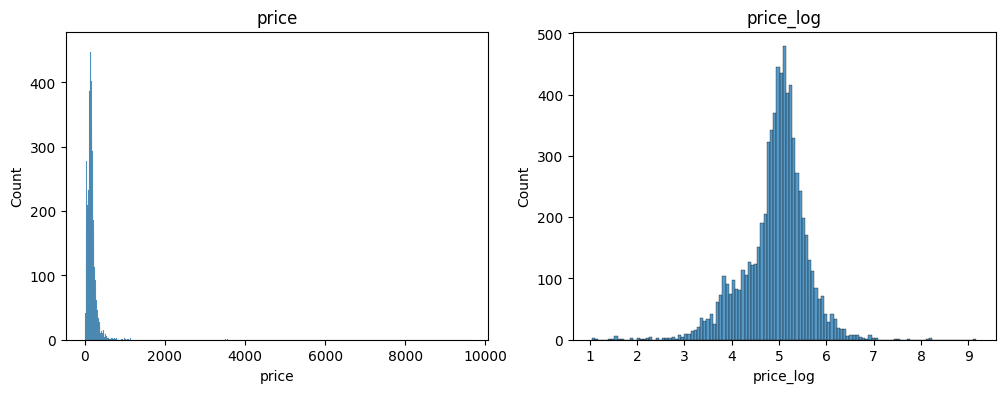

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")

La distribución pasa de una cola muy larga a una forma mucho más cercana a la normal, igual que en Barcelona.

### 3.2 Ratios

`price_per_accommodate` normaliza el precio por la capacidad del alojamiento. Se usa `accommodates` como denominador porque nunca vale 0. `price_per_min_night` es el mismo ratio que en Barcelona/Madrid, aplicado aquí.

In [9]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,7234.000000,7234.000000
mean,50.276877,104.000424
std,65.966725,123.700560
min,0.935000,0.005123
25%,32.750000,16.055455
50%,43.290833,76.500000
75%,58.743750,156.123750
max,4796.550000,3557.000000


<Axes: xlabel='price_per_accommodate', ylabel='Count'>

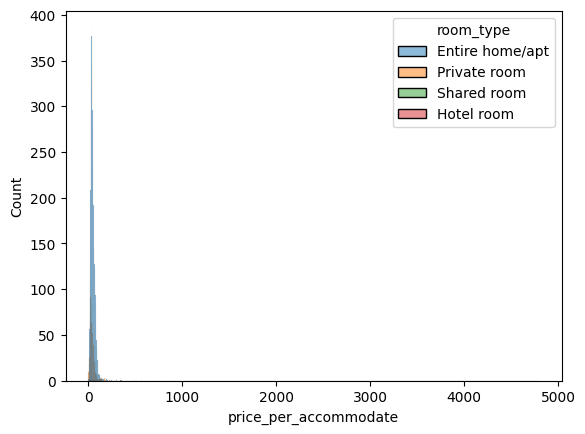

In [10]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")

## 4. Variables de tamaño: multicolinealidad

`accommodates`, `bedrooms`, `beds` y `bathrooms` están correlacionadas entre sí. Decidir si se mantienen todas, se combinan en un índice, o se descarta alguna.

La correlación entre estas cuatro (0.39-0.77 en la EDA, algo más moderada que en Barcelona) es alta a simple vista, pero eso no basta para decidir. Se calcula el VIF (Variance Inflation Factor): a partir de 5, y sobre todo de 10, se considera multicolinealidad seria.

In [11]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]

corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    2.69601
bedrooms        2.16555
beds            2.73446
bathrooms       1.30282
Name: VIF, dtype: float64

Los cuatro VIF están entre 1.3 y 2.7, incluso más bajos que en Barcelona (1.8-4.3). `bathrooms` vuelve a ser la que menos se solapa con las otras tres (VIF 1.30). Se mantienen las cuatro tal cual, sin combinarlas ni descartar ninguna.

Como en Barcelona, esto solo importaría de verdad para un modelo lineal. Si más adelante los coeficientes de estas variables salen inestables entre folds, este es el sitio al que volver.

## 5. Codificación de categóricas

`room_type`, `neighbourhood_group_cleansed`, `neighbourhood_cleansed` y `property_type`: agrupar categorías raras donde haga falta y codificar.

Las cuatro necesitan tratamientos distintos según su cardinalidad: `room_type` y `neighbourhood_group_cleansed` son pocas categorías y se codifican directamente; `neighbourhood_cleansed` (84 barrios) y `property_type` (41 tipos) tienen demasiadas para un one-hot directo.

### 5.1 `room_type`

4 categorías sin orden natural: one-hot encoding.

In [12]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_group_cleansed`

19 categorías (los distritos de Valencia, más del doble que los 10 de Barcelona) sin orden natural: mismo tratamiento.

In [13]:
df = pd.get_dummies(df, columns=["neighbourhood_group_cleansed"], prefix="district")

### 5.3 `neighbourhood_cleansed`

84 categorías: un one-hot directo generaría 84 columnas casi todas dispersas, todavía más que en Barcelona. Se usa **target encoding suavizado**: cada barrio se sustituye por su precio medio, mezclado con el precio medio global cuando el barrio tiene pocos anuncios.

**Aviso importante**: esta media se calcula aquí con todo el dataset, solo para tener la columna disponible y poder seguir explorando en el resto de este notebook — no es la versión final. Antes de entrenar un modelo de verdad hay que recalcularla usando únicamente los datos de entrenamiento, o se estaría filtrando información del conjunto de test al de entrenamiento. Por eso `neighbourhood_cleansed` (la columna cruda) se mantiene más allá de la limpieza final de la sección 10, en vez de descartarse aquí mismo: la corrección real ocurre en `03_model_baseline.ipynb`, justo después del split.

In [14]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [15]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False).head(10)

,neighbourhood_cleansed,neighbourhood_price_encoded
90,La Seu,241.263982
21,Penya-Roja,214.160788
23,Cami Fondo,206.894918
499,Ciutat Fallera,199.984359
17,El Mercat,199.745786
45,Sant Francesc,197.607269
30,Ciutat de les Arts i de les Ciencies,195.820267
1,Cabanyal-Canyamelar,195.173084
716,Carpesa,194.626946
12,Russafa,191.958781


`La Seu` (el barrio de la Catedral, dentro de `Ciutat Vella`) encabeza la lista, coherente con ser el núcleo histórico-turístico más céntrico de la ciudad.

### 5.4 `property_type`

41 categorías, pero muy concentradas: `Entire rental unit` y `Private room in rental unit` son el 78.8% del dataset, y 27 de las 41 categorías tienen menos de 30 anuncios. Igual que en Barcelona, aquí sí interesa agrupar en "Otros" antes de codificar: tras agrupar quedan 15 categorías (14 propias + `Other`), un one-hot manejable.

In [16]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

15

In [17]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

Con esto, `room_type`, `neighbourhood_group_cleansed` y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` como una única columna numérica (`neighbourhood_price_encoded`). `property_type` (texto) se descarta en la limpieza final de la sección 10. `neighbourhood_cleansed` (texto) se mantiene hasta después del split en `03_model_baseline.ipynb`, como se explicó en 5.3.

## 6. Variables derivadas del host

Señales sobre el tipo de host a partir de `calculated_host_listings_count`, `host_is_superhost` y la antigüedad.

### 6.1 Antigüedad del host

In [18]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    7234.000000
mean        5.769388
std         3.867332
min         0.000000
25%         2.333333
50%         4.750000
75%         9.166667
max        15.416667
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

Antes de convertir `calculated_host_listings_count` en un flag binario, se comprueba qué umbral tendría sentido.

In [19]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 73.6%
más de 2 anuncios: 61.8%
más de 5 anuncios: 43.9%
más de 10 anuncios: 31.0%


Con `> 1` ya se marca al 73.6% como "profesional" (la mediana de `calculated_host_listings_count` es 4, frente a 12 en Barcelona: el mercado valenciano está algo menos dominado por hosts con carteras enormes, pero sigue siendo mayoría). Un flag binario no distingue lo suficiente. Se construyen las mismas 4 categorías que en Barcelona/Madrid, por umbrales redondos: `individual` (1 anuncio), `pequeno` (2-10), `mediano` (11-50) y `grande` (51+).

In [20]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,1909,148.67
pequeno,3084,146.00
mediano,1510,150.00
grande,731,172.00


Casi monótona (148.67€ → 146.00€ → 150.00€ → 172.00€), con un ligero bache en `pequeno` que rompe el orden estricto. Como en Barcelona, se prefiere no asumir un orden numérico limpio y se codifica con one-hot.

In [21]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

`calculated_host_listings_count_entire_homes` frente al total del host: qué proporción de los anuncios de ese host son pisos enteros.

In [22]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.26589474155859083)

0.27 de correlación con `price`, notablemente mejor que la del propio `calculated_host_listings_count` (0.08) — una diferencia todavía mayor que en Barcelona (0.23 vs. 0.21). En Valencia, saber *cuántos* anuncios tiene un host aporta poco; saber *qué tipo* de anuncios gestiona aporta bastante más.

## 7. Variables derivadas de reviews

Señales a partir de `review_scores_rating` y compañía, teniendo en cuenta que una parte de los anuncios no tiene reviews todavía.

### 7.1 `has_reviews`

El 10.9% de los anuncios no tiene reviews todavía. Se deja explícito con un flag.

In [23]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     6443
False     791
Name: count, dtype: int64

### 7.2 Antigüedad y recencia de reviews

Se usa la `last_review` más reciente de todo el dataset como fecha de referencia ('hoy' aproximado).

In [24]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,6443.000000,6443.000000
mean,1232.320658,138.339904
std,1113.198183,305.815003
min,6.000000,0.000000
25%,427.000000,17.000000
50%,836.000000,31.000000
75%,1657.500000,101.000000
max,5742.000000,3962.000000


Ambas quedan `NaN` para los anuncios sin reviews, coherente con `has_reviews`. Aquí la correlación con `price` es todavía más débil que en Barcelona (0.04 en `listing_age_days`, prácticamente 0 en `days_since_last_review`), pero se mantienen igualmente: son información real que antes estaba encerrada en un texto de fecha.

In [25]:
df["listing_age_days"].corr(df["price"]), df["days_since_last_review"].corr(df["price"])

(np.float64(0.0387667806756868), np.float64(-0.002783388522446597))

### 7.3 Los 6 subscores de review

Correlacionan entre 0.56 y 0.88 con `review_scores_rating`, y tienen prácticamente los mismos nulos. Misma redundancia que ya se resolvió con las familias de la sección 2: se conserva `review_scores_rating` como resumen y se descartan los 6 subscores.

In [26]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

`review_scores_rating` se deja como `NaN` para los anuncios sin reviews, sin imputar: en la EDA apenas correlaciona con `price` (~0.03-0.05), inventar un valor no aportaría nada.

## 8. Variables geográficas

Alguna codificación adicional de `latitude`/`longitude` más allá del barrio.

### 8.1 Distancia al centro

`neighbourhood_price_encoded` (sección 5) es discreta: dos anuncios muy cerca pero a cada lado de la frontera de un barrio tendrían valores distintos sin motivo real. La distancia en línea recta al centro (Plaza del Ayuntamiento, referencia habitual de Valencia) da una versión continua del mismo patrón espacial.

In [27]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat, center_lon = 39.4699, -0.3763  # Plaza del Ayuntamiento
df["distance_to_center_km"] = haversine(df["latitude"], df["longitude"], center_lat, center_lon)

df["distance_to_center_km"].describe()

count    7234.000000
mean        2.260362
std         2.042964
min         0.000000
25%         0.991520
50%         1.872339
75%         3.181999
max        22.788685
Name: distance_to_center_km, dtype: float64

In [28]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"])

(np.float64(-0.024284846366715), np.float64(-0.11677826388421297))

**Diferencia clara con Barcelona**: aquí la correlación con `price` es prácticamente nula (-0.02, frente a -0.11 en Barcelona) y con `neighbourhood_price_encoded` es bastante más débil (-0.12 frente a -0.43). Tiene una explicación geográfica directa: en la EDA (sección 9 y 11) se vio que Valencia tiene **dos polos caros distintos** — el centro histórico (`Ciutat Vella`) y la franja de playa (`Poblats Marítims`) — que no están en la misma dirección desde la Plaza del Ayuntamiento. Una distancia en línea recta a un único punto mezcla "cerca del centro" y "cerca de la playa" en direcciones opuestas, y el efecto de cada polo se cancela parcialmente. `distance_to_center_km` se mantiene igualmente, como complemento (no sustituto) de `neighbourhood_price_encoded`, que sí captura ambos polos por separado.

Text(0, 0.5, 'log1p(price)')

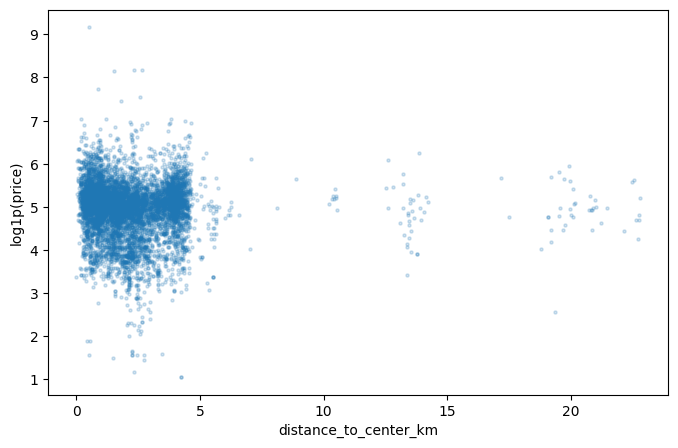

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df["distance_to_center_km"], np.log1p(df["price"]), s=5, alpha=0.2)
plt.xlabel("distance_to_center_km")
plt.ylabel("log1p(price)")

La nube de puntos confirma la lectura: no hay una tendencia decreciente clara, a diferencia del mismo gráfico en Barcelona. Es la prueba visual de que un único centro no describe bien la geografía del precio en Valencia.

### 8.2 Densidad de anuncios cercanos

Motivado en la sección 11.6 de la EDA: cuántos otros anuncios reales hay en un radio de 150 metros de cada uno.

In [30]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    7234.000000
mean       38.653027
std        31.315984
min         0.000000
25%        15.000000
50%        30.000000
75%        56.000000
max       163.000000
Name: n_nearby_150m, dtype: float64

Mismo resultado que en la EDA (media ~39, mediana 30): correlación modesta con `price` (0.10), similar a Barcelona. A diferencia de `distance_to_center_km`, esta variable sí sigue aportando señal aquí, porque cuenta densidad real alrededor de cada punto en vez de asumir un único centro.

## 9. Amenities

Se construyen las cuatro variables motivadas en la sección 12 de la EDA: `has_ac`, `has_pool` y `has_dishwasher` (flags por palabra clave) y `n_amenities` (recuento total). Un one-hot directo de las 1820 categorías de `amenities` no es viable (57% son variantes que aparecen una sola vez).

### 9.1 Parsear y construir los flags

In [31]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)

def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"]))
df["has_dishwasher"] = amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_dishwasher", "n_amenities"]].describe()

,n_amenities
count,7234.000000
mean,32.009538
std,14.283217
min,0.000000
25%,22.000000
50%,33.000000
75%,42.000000
max,92.000000


Prevalencias consistentes con la EDA (`has_ac` ~87%, `has_dishwasher` ~37%, `has_pool` ~3%, `n_amenities` media ~32). `has_pool` sigue siendo la más prometedora de las tres pese a su baja prevalencia: en la EDA correlacionaba 0.21 con `price`, muy por encima del 0.04 de Barcelona — una piscina privada distingue más en una ciudad de playa.

### 9.2 Descartar `amenities`

Ya cumplió su función: se descarta el texto crudo.

In [32]:
df = df.drop(columns=["amenities"])
df.shape

(7234, 98)

## 10. Dataset final para modelado

Selección de las columnas finales y guardado en `data/processed/valencia/` para los notebooks de modelado.

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

En la sección 6 se combinó la antigüedad como host, pero se quedó sin tocar la antigüedad como usuario de Airbnb en general. Se combina igual, por coherencia.

In [33]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

Se descartan las columnas ya sustituidas por una versión mejor: `property_type` en texto, las cuatro columnas de antigüedad ya combinadas, `first_review`/`last_review` en formato fecha, y el desglose `calculated_host_listings_count_entire_homes`/`_private_rooms`/`_shared_rooms` (ya resumido en `host_entire_homes_ratio`).

`neighbourhood_cleansed` es la excepción, no se descarta aquí: se mantiene para que `03_model_baseline.ipynb` recalcule `neighbourhood_price_encoded` solo con train justo después del split.

In [34]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=final_drop)
df.shape

(7234, 89)

### 10.3 Comprobación de nulos

Debería quedar solo lo que se dejó así a propósito: todo lo relacionado con anuncios sin reviews todavía.

In [35]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      791
listing_age_days          791
days_since_last_review    791
dtype: int64

Las tres coinciden exactamente en las mismas 791 filas (`has_reviews == False`), tal y como se esperaba. El único caso especial visto en la EDA/sección 7.3 (un anuncio con 1 review pero sin `review_scores_accuracy`) no aparece aquí porque ese subscore concreto ya se descartó en la sección 7.3. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

`id`, `host_id` y `host_profile_id` son referencias, no entran como input del modelo; `price` es la variable objetivo; `neighbourhood_cleansed` viaja en el CSV pero todavía no es una feature (pendiente de la corrección de fuga en `03_model_baseline.ipynb`); el resto son las features.

In [36]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 84


89 columnas en total: 3 identificadores, 1 objetivo, 1 pendiente y **84 features**, un número similar al de Barcelona/Madrid pese a tener más distritos (19 dummies de `district_*` en vez de 10).

### 10.5 Exportar

In [37]:
df.to_csv(f"{PROJECT_DIR}/data/processed/valencia/listings_full_features.csv", index=False)